In [58]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler   # Library for data preprocessing
from sklearn.decomposition import PCA              # Library for Principal Component Analysis
import shap                                        # Library for SHAP (SHapley Additive exPlanations)
from sklearn.svm import SVR                         # Support Vector Regression from scikit-learn
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split  # Tools for model evaluation and tuning
from sklearn.model_selection import KFold           # K-Fold cross-validation
import xgboost as xgb                               # XGBoost library for gradient boosting

In [60]:
# Defining column headers for the DataFrame
headerList = ['#', 'gold', 'silver', 'CTAB', 'I-2959','UV_Inten', 'time', 'os', 'num_peak','wl1', 'FWHM1', 'ISPR1', 'wl2', 'FWHM2','ISPR2','I400','note']

# Reading data from a CSV file with custom column names
data = pd.read_csv(r"NR_raw_data.csv", names=headerList)

# Removing the first row (assumed to be headers) to keep only the data
data = data.iloc[1:]

# Creating a copy of the DataFrame for numeric data conversion
data_num = data.copy()

# Specifying the columns to be converted to numeric
numeric = ['gold', 'silver', 'CTAB', 'I-2959', 'UV_Inten', 'time', 'os', 'wl1', 'FWHM1', 'ISPR1', 'wl2', 'FWHM2', 'ISPR2', 'I400']

# Converting specified columns to numeric, handling any errors
data_num[numeric] = data_num[numeric].apply(pd.to_numeric, errors='coerce')

# Displaying the DataFrame with numeric data
# data_num

# Gold Nanorods

In [61]:
data_R = data_num.copy()
data_R['IR'] = data_R['ISPR1']/data_R['I400']
# data_R

In [62]:
def trainModel(X, y):
    """
    Train a model using XGBoost with hyperparameter tuning.
    
    Parameters:
    - X: Features data for training.
    - y: Target labels for training.
    
    Returns:
    - clf: Trained model with the best hyperparameters.
    """
    
    # Hyperparameter grid for tuning
    params = {
        'max_depth': [3, 5, 7],                  # Maximum depth of trees
        'learning_rate': [0.05, 0.1, 0.15],       # Learning rate for boosting
        'n_estimators': [100, 150, 200],         # Number of boosting rounds
        'colsample_bytree': [0.3, 0.6, 0.9]            # Fraction of features used for each tree
    }
    
    # Creating an XGBoost classifier model
    model = xgb.XGBRegressor()
    
    # Initializing GridSearchCV for hyperparameter tuning
    clf = GridSearchCV(estimator=model, param_grid=params, scoring='r2', cv=10)
    
    # Fitting the classifier to the training data
    clf.fit(X, y)
    
    return clf


In [63]:
def shap_analysis(X, y, model, target):
    """
    Perform SHAP analysis on the given model using the provided data.
    
    Parameters:
    - X: Features data for analysis.
    - y: Target labels for analysis.
    - model: Trained model for analysis.
    
    Returns:
    None
    """
    
    # Creating a SHAP explainer using the model's predictions
    explainer = shap.KernelExplainer(model.predict, X)
    
    # Calculating SHAP values
    shap_values = explainer.shap_values(X)
    
    # Creating a summary plot of SHAP values
    shap.summary_plot(shap_values, features=X, feature_names=X.columns, title=target, show=False)
    
    # Saving the summary plot as an image file
    plt.title(target)
    plt.savefig(target + '_AuNR.png', bbox_inches='tight', dpi=300)
    plt.show()

In [65]:
# Defining the list of features and targets
features = ['gold', 'silver', 'CTAB', 'I-2959', 'UV_Inten', 'time', 'os']
targets = ['wl1', 'FWHM1', 'IR']

for t in targets:
    X_train, X_test, y_train, y_test = train_test_split(data_R[features], data_R[t], test_size=0.2)
    model = trainModel(X_train, y_train)
    print (t, 'train-cv', model.best_params_)

wl1 train-cv {'colsample_bytree': 0.3, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
FWHM1 train-cv {'colsample_bytree': 0.3, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
IR train-cv {'colsample_bytree': 0.3, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


  0%|          | 0/69 [00:00<?, ?it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


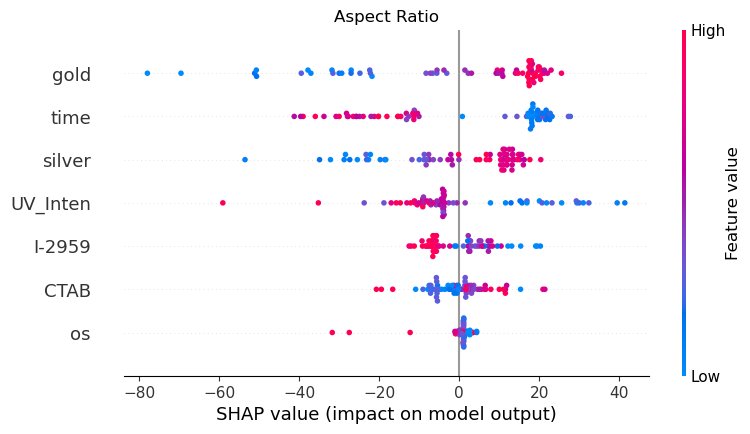

In [32]:
t = 'Aspect Ratio'
X = data_R[features]
y = data_R['wl1']

best_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'learning_rate': 0.1,
    'colsample_bytree': 0.6
}
model = xgb.XGBRegressor(**best_params)
model.fit(X,y)

shap_analysis(X, y, model, t)

  0%|          | 0/69 [00:00<?, ?it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


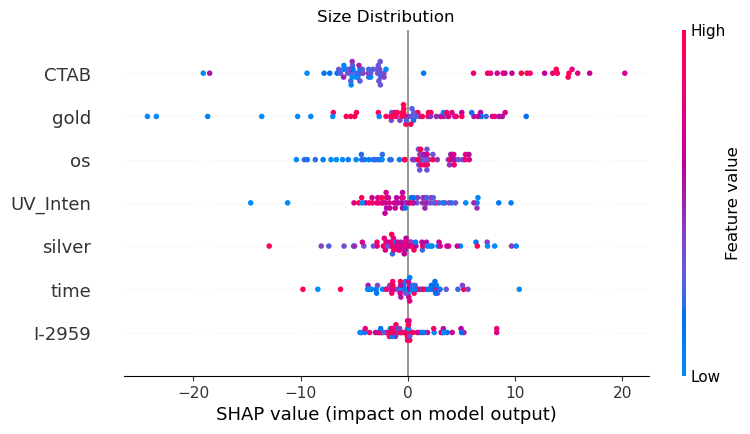

In [55]:
t = 'Size Distribution'
X = data_R[features]
y = data_R['FWHM1']

best_params = {
    'n_estimators': 100,
    'max_depth': 7,
    'learning_rate': 0.1,
    'colsample_bytree': 0.5
}
model = xgb.XGBRegressor(**best_params)
model.fit(X,y)

shap_analysis(X, y, model, t)

  0%|          | 0/69 [00:00<?, ?it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


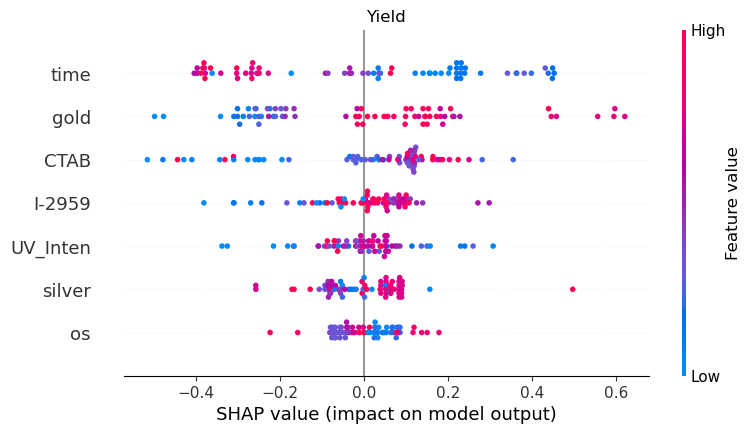

In [57]:
t = 'Yield'
X = data_R[features]
y = data_R['IR']

best_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'learning_rate': 0.1,
    'colsample_bytree': 0.3
}
model = xgb.XGBRegressor(**best_params)
model.fit(X,y)

shap_analysis(X, y, model, t)